In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from torch.utils.tensorboard import SummaryWriter
import seaborn as sns
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import numpy as np

from shapely.geometry import Point
from shapely.geometry.polygon import Polygon
import datetime

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime
import matplotlib.colors as mcolors

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [6]:
Data = pd.read_csv('Modis_DataSet_2023.csv')

In [7]:
print(Data.head())

    Timestamp  Coverage_Area   Longitude   Latitude      Volume  Days
0  2023-06-01       4.559304  120.600824  33.360801  103.814691     0
1  2023-06-02       1.393396  119.962293  32.741599    9.650902     1
2  2023-06-03      21.677273  122.212261  34.004605  556.616562     2
3  2023-06-04       0.966014  122.266174  35.688613   64.582828     3
4  2023-06-05       0.452023  120.142003  35.246204   12.872321     4


In [8]:
Col = ['Coverage_Area', 'Volume', 'Days', 'Longitude', 'Latitude']

COL = Data['Days']
data = Data[Col]

# 计算差分
data_Copy = data
data_Copy['Diff'] = data_Copy['Coverage_Area'].diff().abs()

# 设定阈值
threshold = data_Copy['Diff'].mean() + 2 * data_Copy['Diff'].std()
data_Copy['Outlier'] = data_Copy['Diff'] > threshold

# 标记异常值
data_Copy['Is_Outlier'] = data_Copy['Outlier']

# 将异常值替换为 NaN
# data.loc[data_Copy['Is_Outlier'], 'Coverage_Area'] = np.nan
data.loc[data_Copy['Is_Outlier']] = np.nan

C:\Users\14390\AppData\Local\Temp\ipykernel_99540\2328813211.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  data.loc[data_Copy['Is_Outlier']] = np.nan
C:\Users\14390\AppData\Local\Temp\ipykernel_99540\2328813211.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  data.loc[data_Copy['Is_Outlier']] = np.nan


In [9]:
data['Days'] = COL

data.interpolate(method='polynomial', order=3, inplace=True)
data = data.interpolate()

C:\Users\14390\AppData\Local\Temp\ipykernel_99540\4156011059.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data.interpolate(method='polynomial', order=3, inplace=True)
C:\Users\14390\AppData\Local\Temp\ipykernel_99540\4156011059.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data = data.interpolate()


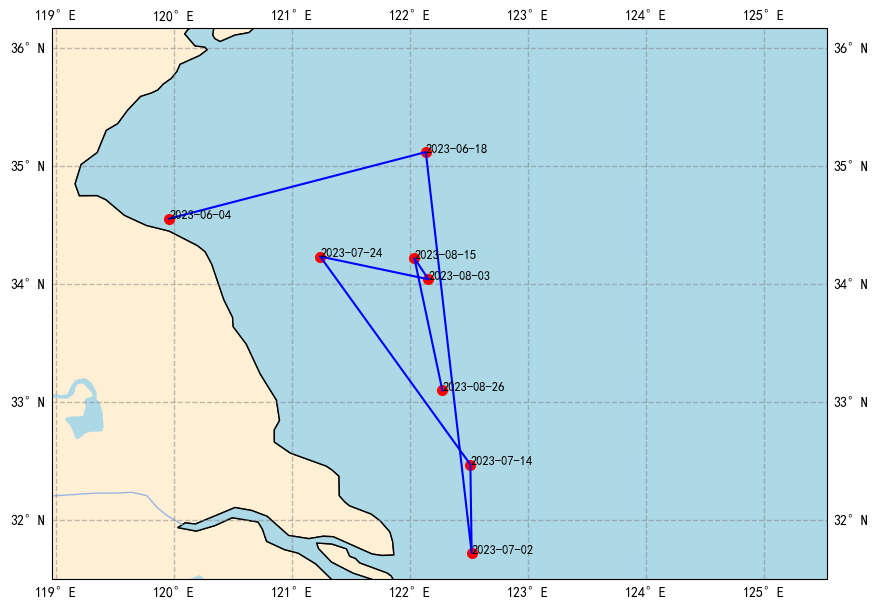

In [10]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([118.9667, 125.5333, 31.5, 36.1667])

# 添加特征
ax.add_feature(cfeature.LAND.with_scale('50m'), edgecolor='black', facecolor='papayawhip', zorder=0)
ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='lightblue', zorder=0)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), zorder=1)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=':', zorder=1)
ax.add_feature(cfeature.LAKES.with_scale('50m'), facecolor='lightblue', zorder=0)
ax.add_feature(cfeature.RIVERS.with_scale('50m'), zorder=1)

# 添加格网线
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle = '--')
start_date = datetime.date(2023, 6, 1)

# 获取陆地多边形
land_polygons = [feature for feature in cfeature.NaturalEarthFeature('physical', 'land', '10m').geometries()]

# 检查每个点是否在陆地上
def is_on_land(lon, lat):
    point = Point(lon, lat)
    for polygon in land_polygons:
        if polygon.contains(point):
            return True
    return False

# 绘制点并检查
lons = data['Longitude'].values
lats = data['Latitude'].values
days = data['Days'].values
ocean_points = []

for lon, lat, day in zip(lons, lats, days):
    if not is_on_land(lon, lat):
        day = int(day)
        date = start_date + datetime.timedelta(days=day)
        ocean_points.append((lon, lat, date))

if ocean_points:
    ocean_points = np.array(ocean_points, dtype=object)
    ocean_points = ocean_points[::7]  # 每7天采样一个点
    for lon, lat, date in ocean_points:
        ax.plot(lon, lat, marker='o', color='red', markersize=7, transform=ccrs.Geodetic())
        ax.text(lon, lat, date.strftime('%Y-%m-%d'), transform=ccrs.Geodetic(), fontsize=9, ha='left')

    # 连接这些点
    ax.plot(ocean_points[:, 0], ocean_points[:, 1], linestyle='-', color='blue', transform=ccrs.Geodetic())

plt.show()

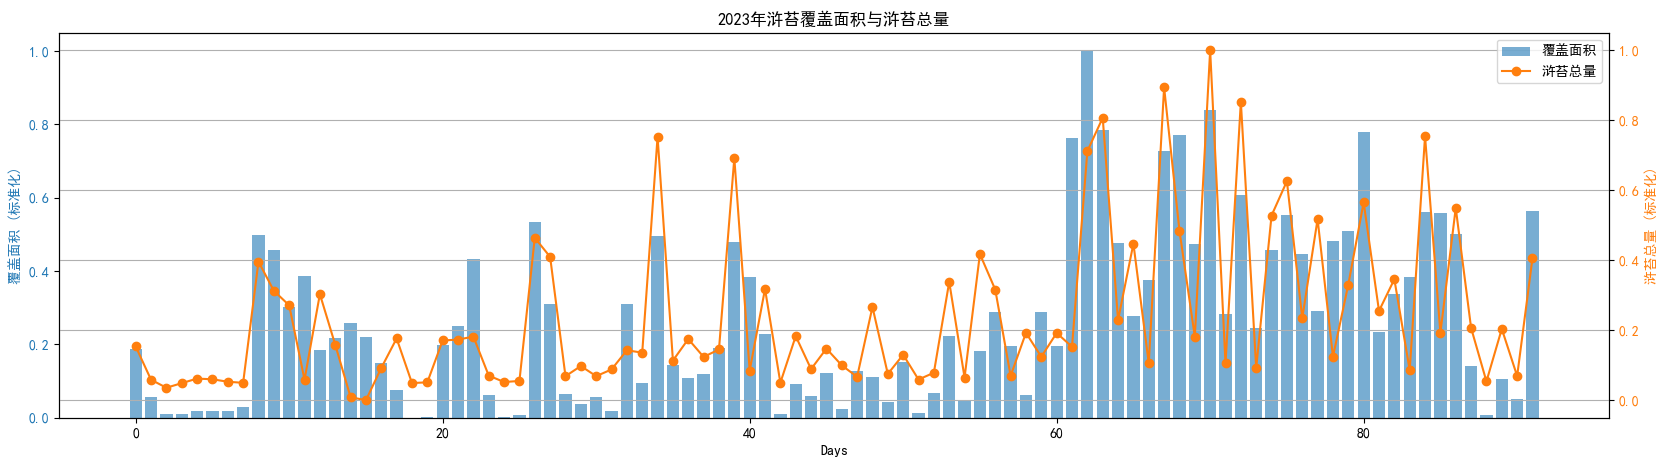

In [11]:
# 创建图形和轴
# plt.figure(figsize=(100, 20))
fig, ax1 = plt.subplots(figsize=(20, 5))

# 数据标准化
scaler_coverage = MinMaxScaler()
data['Coverage_Area'] = scaler_coverage.fit_transform(data['Coverage_Area'].values.reshape(-1, 1))

scaler_volume = MinMaxScaler()
data['Volume'] = scaler_volume.fit_transform(data['Volume'].values.reshape(-1, 1))


# 直方图，使用bar绘制
# coverage_counts = data['Coverage_Area'].value_counts()
ax1.bar(data['Coverage_Area'].index, data['Coverage_Area'].values, color='tab:blue', alpha=0.6, label='覆盖面积')
ax1.set_xlabel('Days')
ax1.set_ylabel('覆盖面积 (标准化)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# 创建第二个轴，共用x轴
ax2 = ax1.twinx()
ax2.plot(data['Volume'].index, data['Volume'].values, 'o-', color='tab:orange', label='浒苔总量')
ax2.set_ylabel('浒苔总量 (标准化)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# 添加图例
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

# 显示图表
plt.title('2023年浒苔覆盖面积与浒苔总量')
plt.grid()
plt.show()


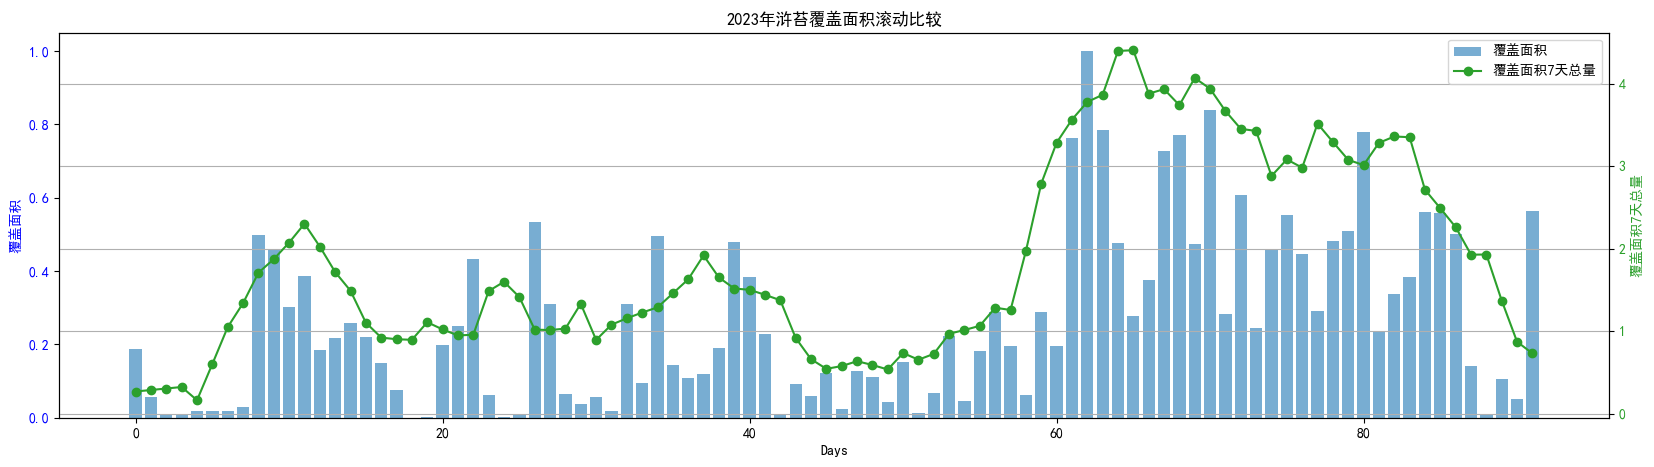

In [12]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 创建图形和轴
# plt.figure(figsize=(100, 20))
fig, ax1 = plt.subplots(figsize=(20, 5))

# 计算滚动窗口的总和
window_size = 7  # 当天 + 前3天 + 后3天
centered_sum = data['Coverage_Area'].rolling(window=window_size, min_periods=1, center=True).sum()


# 直方图，使用bar绘制
# coverage_counts = data['Coverage_Area'].value_counts()
ax1.bar(data['Coverage_Area'].index, data['Coverage_Area'].values, color='tab:blue', alpha=0.6, label='覆盖面积')
ax1.set_xlabel('Days')
ax1.set_ylabel('覆盖面积', color='b')
ax1.tick_params(axis='y', labelcolor='b')


# 创建第二个轴，共用x轴
ax2 = ax1.twinx()
# ax2.plot(data['Volume'].index, data['Volume'].values, 'o-', color='tab:orange', label='Total Volume')
ax2.plot(data['Volume'].index, centered_sum.values, 'o-', color='tab:green', label='覆盖面积7天总量')
ax2.set_ylabel('覆盖面积7天总量', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')



# 添加图例
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

# 显示图表
plt.title('2023年浒苔覆盖面积滚动比较')
plt.grid()
plt.show()


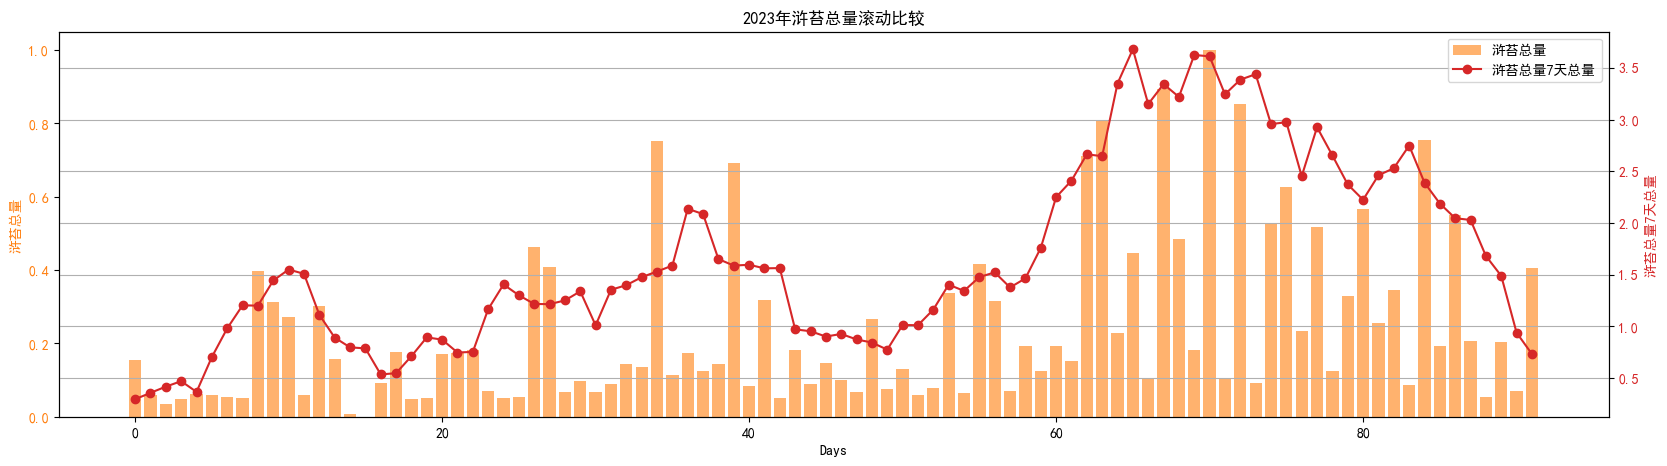

In [13]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 创建图形和轴
# plt.figure(figsize=(100, 20))
fig, ax1 = plt.subplots(figsize=(20, 5))

# 计算滚动窗口的总和
window_size = 7  # 当天 + 前3天 + 后3天
centered_sum = data['Volume'].rolling(window=window_size, min_periods=1, center=True).sum()


# 直方图，使用bar绘制
# coverage_counts = data['Coverage_Area'].value_counts()
ax1.bar(data['Volume'].index, data['Volume'].values, color='tab:orange', alpha=0.6, label='浒苔总量')
ax1.set_xlabel('Days')
ax1.set_ylabel('浒苔总量', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:orange')


# 创建第二个轴，共用x轴
ax2 = ax1.twinx()
# ax2.plot(data['Volume'].index, data['Volume'].values, 'o-', color='tab:orange', label='Total Volume')
ax2.plot(data['Volume'].index, centered_sum.values, 'o-', color='tab:red', label='浒苔总量7天总量')
ax2.set_ylabel('浒苔总量7天总量', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')



# 添加图例
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

# 显示图表
plt.title('2023年浒苔总量滚动比较')
plt.grid()
plt.show()


时序预测模型

In [14]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

In [15]:
df = data
# df.sort_values('Timestamp', inplace=True)
Len = 3


def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

# 选择特征列
# features = ['Coverage_Area', 'Longitude', 'Latitude', 'Volume', 'Days']
features_1 = ['Coverage_Area', 'Volume', 'Days']
features_2 = ['Coverage_Area', 'Volume']
time_steps = Len
X, y = create_dataset(df[features_1], df[features_2], time_steps)

# 分割数据集，这里使用80%的数据作为训练集，20%的数据作为测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 转换为PyTorch张量
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# 创建数据加载器
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=4, shuffle=True)

test_data = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_data, batch_size=4, shuffle=False)


print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


torch.Size([71, 3, 3]) torch.Size([71, 2])
torch.Size([18, 3, 3]) torch.Size([18, 2])


In [16]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, states=None):
        if states is None:
            # Automatically allocate device
            h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device)
            c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device)
            states = (h0, c0)
        out, (hn, cn) = self.lstm(x, states)
        out = self.fc(out[:, -1, :])  # 取最后一个时间步
        return out, (hn, cn)

# 实例化模型
model = LSTMModel(input_dim=3, hidden_dim=256, num_layers=5, output_dim=2)

In [17]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.kaiming_uniform_(m.weight)
    #     torch.nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')  # 假设使用ReLU激活函数
    #     if m.bias is not None:
        m.bias.data.fill_(0.01)

model.apply(init_weights)

LSTMModel(
  (lstm): LSTM(3, 256, num_layers=5, batch_first=True)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)

In [18]:
loss_fn = nn.MSELoss()
# optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-2)
# 训练模型
num_epochs = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

writer = SummaryWriter(log_dir='runs/LSTM')
best_test_loss = float('inf')
best_model_path = 'Model/LSTM.pth'

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        y_pred, _ = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
    train_loss /= len(train_loader)

    test_loss = 0.0
    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred, _ = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            test_loss += loss.item()
    test_loss /= len(test_loader)

    print(f'Epoch {epoch+1} Train Loss: {train_loss} Test Loss: {test_loss}')
    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('Loss/test', test_loss, epoch)

    # Save the model if the test loss is the best we've seen so far.
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"Saved new best model with Test Loss: {test_loss}")

writer.close()

Epoch 1 Train Loss: 0.06019573244783613 Test Loss: 0.06498154848814011
Saved new best model with Test Loss: 0.06498154848814011
Epoch 2 Train Loss: 0.0588676810471548 Test Loss: 0.06181892156600952
Saved new best model with Test Loss: 0.06181892156600952
Epoch 3 Train Loss: 0.05264064773089356 Test Loss: 0.04170086234807968
Saved new best model with Test Loss: 0.04170086234807968
Epoch 4 Train Loss: 0.05685662757605314 Test Loss: 0.06067578755319118
Epoch 5 Train Loss: 0.051123528430859246 Test Loss: 0.047611478809267284
Epoch 6 Train Loss: 0.053952700872388154 Test Loss: 0.055748123489320275
Epoch 7 Train Loss: 0.04856099307330118 Test Loss: 0.03942722976207733
Saved new best model with Test Loss: 0.03942722976207733
Epoch 8 Train Loss: 0.0508225734035174 Test Loss: 0.05199480094015598
Epoch 9 Train Loss: 0.05394430049798555 Test Loss: 0.06485902350395918
Epoch 10 Train Loss: 0.05456357594165537 Test Loss: 0.06119740195572376
Epoch 11 Train Loss: 0.0558434734120965 Test Loss: 0.054725

In [19]:
print(best_test_loss)

0.03086454775184393


In [548]:
model.load_state_dict(torch.load('Model/LSTM.pth'))

<All keys matched successfully>

In [549]:
model.eval()
model.to(device)

LSTMModel(
  (lstm): LSTM(3, 256, num_layers=5, batch_first=True)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)

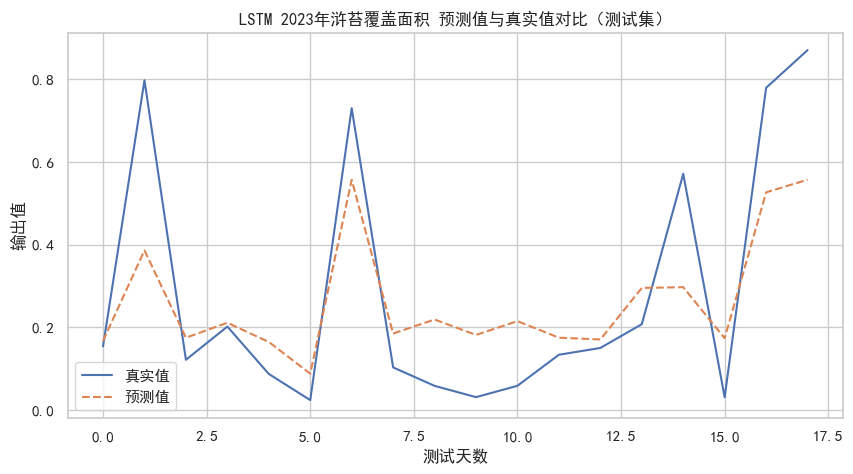

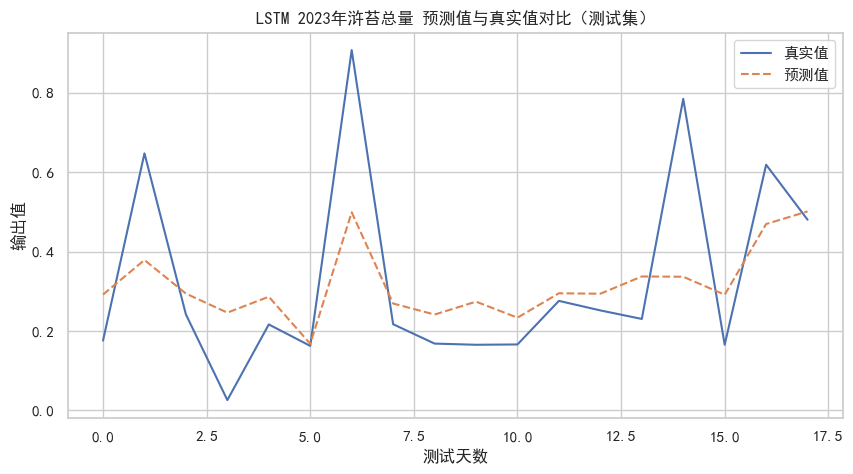

In [550]:
predictions = []
true_values = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_pred, _ = model(X_batch)
        predictions.extend(y_pred.cpu().numpy())
        true_values.extend(y_batch.cpu().numpy())

predictions = np.array(predictions)
true_values = np.array(true_values)

# # 设置 Seaborn 的图形风格
import matplotlib
# 设置字体族为 'sans-serif'
rc = {'font.sans-serif': 'SimHei',
      'axes.unicode_minus': False}
sns.set(style='whitegrid', rc=rc)
plt.figure(figsize=(10, 5))
plt.plot(true_values[:,0], label='真实值')
plt.plot(predictions[:,0], label='预测值', linestyle='--')
plt.title('LSTM 2023年浒苔覆盖面积 预测值与真实值对比（测试集）')
plt.xlabel('测试天数')
plt.ylabel('输出值')
plt.legend()
plt.show()

# # 设置 Seaborn 的图形风格
import matplotlib
# 设置字体族为 'sans-serif'
rc = {'font.sans-serif': 'SimHei',
      'axes.unicode_minus': False}
sns.set(style='whitegrid', rc=rc)
plt.figure(figsize=(10, 5))
plt.plot(true_values[:,1], label='真实值')
plt.plot(predictions[:,1], label='预测值', linestyle='--')
plt.title('LSTM 2023年浒苔总量 预测值与真实值对比（测试集）')
plt.xlabel('测试天数')
plt.ylabel('输出值')
plt.legend()
plt.show()

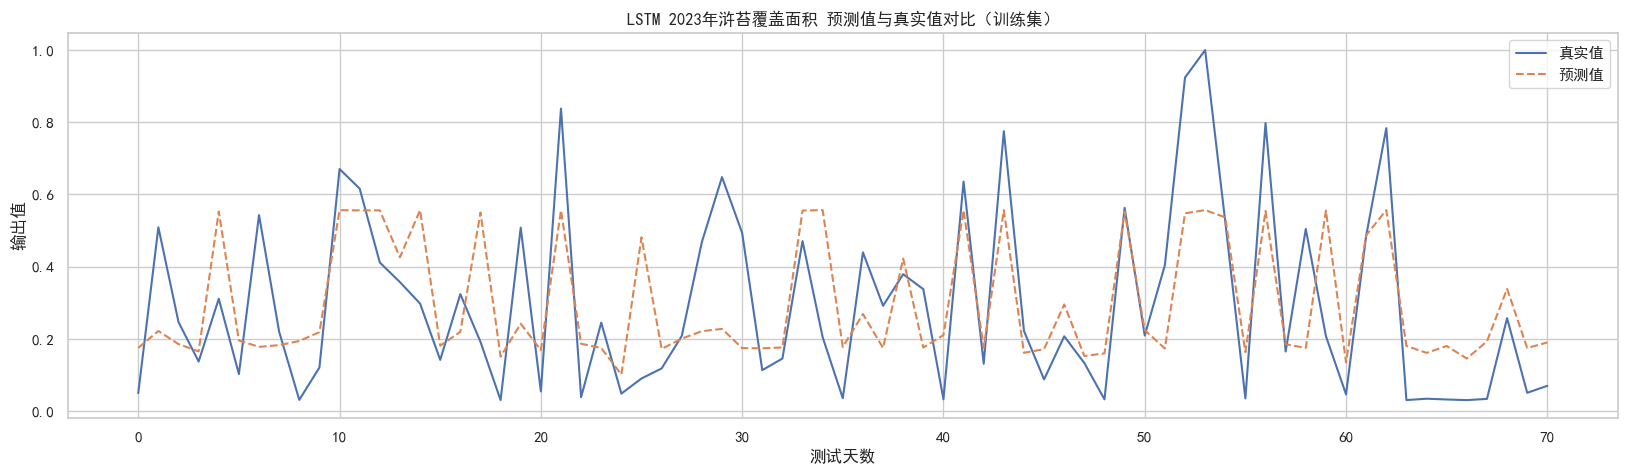

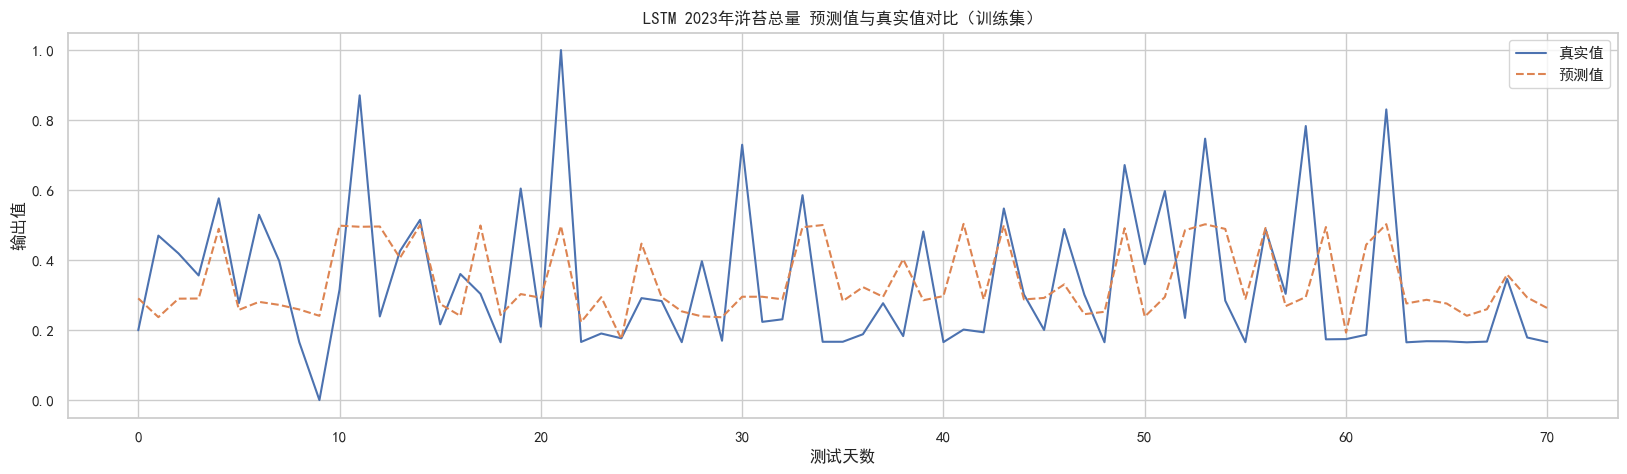

In [551]:
predictions = []
true_values = []

with torch.no_grad():
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_pred, _ = model(X_batch)
        predictions.extend(y_pred.cpu().numpy())
        true_values.extend(y_batch.cpu().numpy())

predictions = np.array(predictions)
true_values = np.array(true_values)

# # 设置 Seaborn 的图形风格
import matplotlib
# 设置字体族为 'sans-serif'
rc = {'font.sans-serif': 'SimHei',
      'axes.unicode_minus': False}
sns.set(style='whitegrid', rc=rc)
plt.figure(figsize=(20, 5))
plt.plot(true_values[:,0], label='真实值')
plt.plot(predictions[:,0], label='预测值', linestyle='--')
plt.title('LSTM 2023年浒苔覆盖面积 预测值与真实值对比（训练集）')
plt.xlabel('测试天数')
plt.ylabel('输出值')
plt.legend()
plt.show()

# # 设置 Seaborn 的图形风格
import matplotlib
# 设置字体族为 'sans-serif'
rc = {'font.sans-serif': 'SimHei',
      'axes.unicode_minus': False}
sns.set(style='whitegrid', rc=rc)
plt.figure(figsize=(20, 5))
plt.plot(true_values[:,1], label='真实值')
plt.plot(predictions[:,1], label='预测值', linestyle='--')
plt.title('LSTM 2023年浒苔总量 预测值与真实值对比（训练集）')
plt.xlabel('测试天数')
plt.ylabel('输出值')
plt.legend()
plt.show()

Informer

In [552]:
class ProbSparseAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.d_k = d_model // num_heads
        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
        
    def forward(self, q, k, v, mask=None):
        # 分头计算
        batch_size = q.size(0)
        q = self.query(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        k = self.key(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        v = self.value(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        # 计算注意力得分
        scores = torch.matmul(q, k.transpose(-2, -1)) / np.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        attn = torch.softmax(scores, dim=-1)
        output = torch.matmul(attn, v).transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return output

class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Encoder, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)

    def forward(self, x):
        outputs, (hidden, cell) = self.lstm(x)
        return outputs, hidden, cell

class Decoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Decoder, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, input_size)  # 假设输出大小与输入大小相同

    def forward(self, x, hidden, cell):
        output, (hidden, cell) = self.lstm(x, (hidden, cell))
        
        prediction = self.fc(output)
        return prediction, hidden, cell


class Informer(nn.Module):
    def __init__(self, input_dim, output_dim, seq_len, pred_len, d_model, num_heads):
        super().__init__()
        self.attention = ProbSparseAttention(d_model, num_heads)
        self.encoder = Encoder(input_dim, d_model)
        self.decoder = Decoder(d_model, d_model)
        self.fc = nn.Linear(d_model, output_dim)
        self.seq_len = seq_len
        self.pred_len = pred_len
        
    def forward(self, x):
        output, hidden, cell = self.encoder(x)
        output = self.attention(output, output, output)
        output, _, _ = self.decoder(output, hidden, cell)
        decoded = self.fc(output[:, -self.pred_len:, :])
        return decoded.squeeze()

In [553]:
# (4,3,3) (4,2)

# 模型参数
input_dim = 3  # 输入特征维度
output_dim = 2  # 输出特征维度
seq_len = Len   # 输入序列长度
pred_len = 1  # 预测序列长度
d_model = 128  # 模型维度
num_heads = 8  # 注意力头数

model = Informer(input_dim, output_dim, seq_len, pred_len, d_model, num_heads)

In [554]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.kaiming_uniform_(m.weight)
    #     torch.nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')  # 假设使用ReLU激活函数
    #     if m.bias is not None:
        m.bias.data.fill_(0.01)

model.apply(init_weights)

Informer(
  (attention): ProbSparseAttention(
    (query): Linear(in_features=128, out_features=128, bias=True)
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
  )
  (encoder): Encoder(
    (lstm): LSTM(3, 128, batch_first=True)
  )
  (decoder): Decoder(
    (lstm): LSTM(128, 128, batch_first=True)
    (fc): Linear(in_features=128, out_features=128, bias=True)
  )
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

In [555]:
loss_fn = nn.MSELoss()
# optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-2)
# 训练模型
num_epochs = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

writer = SummaryWriter(log_dir='runs/Informer')
best_test_loss = float('inf')
best_model_path = 'Model/Informer.pth'

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
    train_loss /= len(train_loader)

    test_loss = 0.0
    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            test_loss += loss.item()
    test_loss /= len(test_loader)

    print(f'Epoch {epoch+1} Train Loss: {train_loss} Test Loss: {test_loss}')
    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('Loss/test', test_loss, epoch)

    # Save the model if the test loss is the best we've seen so far.
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"Saved new best model with Test Loss: {test_loss}")

writer.close()

Epoch 1 Train Loss: 0.09382955419520538 Test Loss: 0.07624405771493911
Saved new best model with Test Loss: 0.07624405771493911
Epoch 2 Train Loss: 0.06584134687566096 Test Loss: 0.06470427736639976
Saved new best model with Test Loss: 0.06470427736639976
Epoch 3 Train Loss: 0.06739327135599321 Test Loss: 0.06342893540859222
Saved new best model with Test Loss: 0.06342893540859222
Epoch 4 Train Loss: 0.0577679347867767 Test Loss: 0.06308672949671745
Saved new best model with Test Loss: 0.06308672949671745
Epoch 5 Train Loss: 0.05349912540987134 Test Loss: 0.06099819093942642
Saved new best model with Test Loss: 0.06099819093942642
Epoch 6 Train Loss: 0.052106403538750276 Test Loss: 0.06008463315665722
Saved new best model with Test Loss: 0.06008463315665722
Epoch 7 Train Loss: 0.04935256236543258 Test Loss: 0.05915346648544073
Saved new best model with Test Loss: 0.05915346648544073
Epoch 8 Train Loss: 0.049083675257861614 Test Loss: 0.060610996559262276
Epoch 9 Train Loss: 0.051515143

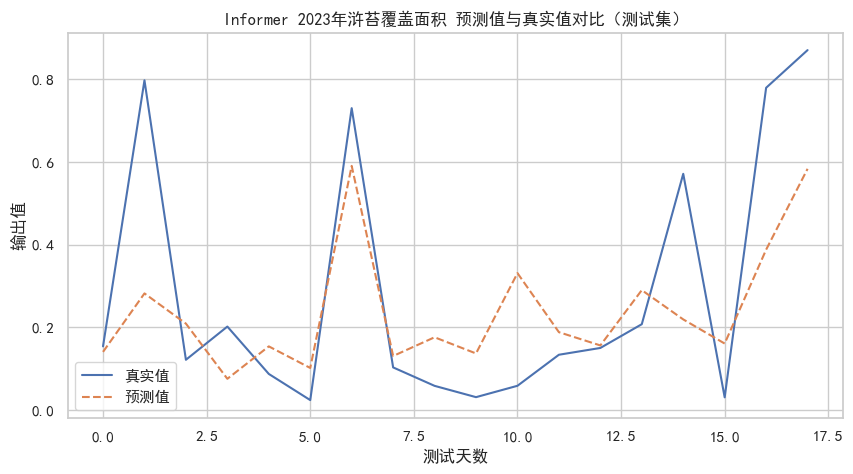

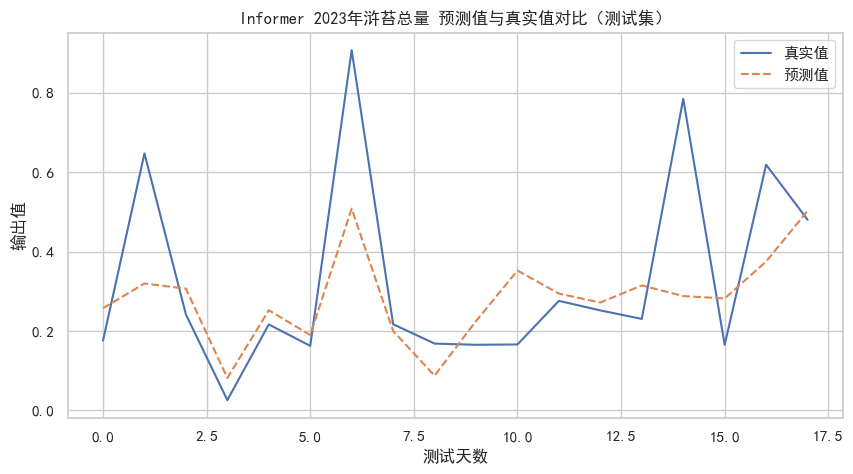

In [556]:
predictions = []
true_values = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_pred = model(X_batch)
        predictions.extend(y_pred.cpu().numpy())
        true_values.extend(y_batch.cpu().numpy())

predictions = np.array(predictions)
true_values = np.array(true_values)

# # 设置 Seaborn 的图形风格
import matplotlib
# 设置字体族为 'sans-serif'
rc = {'font.sans-serif': 'SimHei',
      'axes.unicode_minus': False}
sns.set(style='whitegrid', rc=rc)
plt.figure(figsize=(10, 5))
plt.plot(true_values[:,0], label='真实值')
plt.plot(predictions[:,0], label='预测值', linestyle='--')
plt.title('Informer 2023年浒苔覆盖面积 预测值与真实值对比（测试集）')
plt.xlabel('测试天数')
plt.ylabel('输出值')
plt.legend()
plt.show()

# # 设置 Seaborn 的图形风格
import matplotlib
# 设置字体族为 'sans-serif'
rc = {'font.sans-serif': 'SimHei',
      'axes.unicode_minus': False}
sns.set(style='whitegrid', rc=rc)
plt.figure(figsize=(10, 5))
plt.plot(true_values[:,1], label='真实值')
plt.plot(predictions[:,1], label='预测值', linestyle='--')
plt.title('Informer 2023年浒苔总量 预测值与真实值对比（测试集）')
plt.xlabel('测试天数')
plt.ylabel('输出值')
plt.legend()
plt.show()

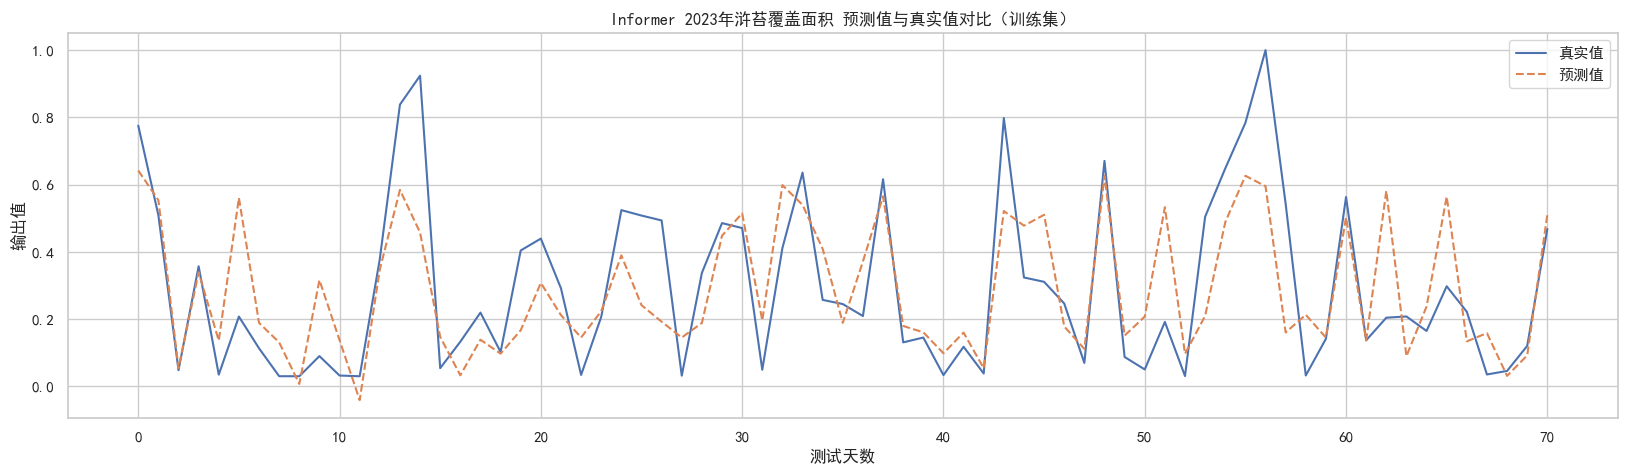

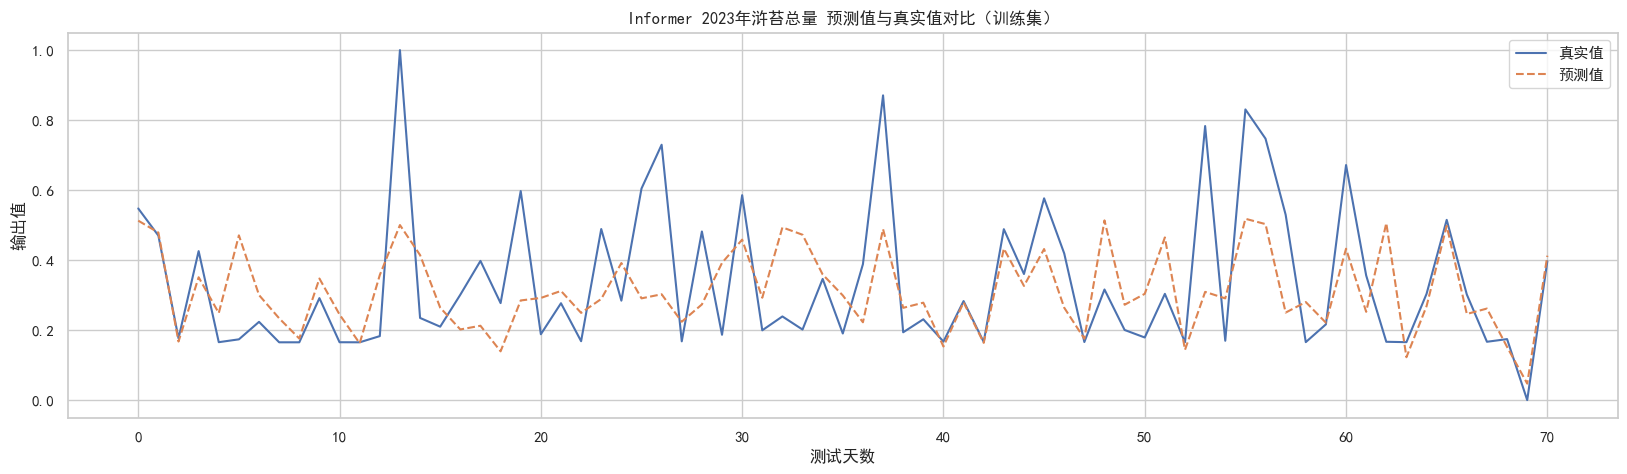

In [557]:
predictions = []
true_values = []

with torch.no_grad():
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_pred = model(X_batch)
        predictions.extend(y_pred.cpu().numpy())
        true_values.extend(y_batch.cpu().numpy())

predictions = np.array(predictions)
true_values = np.array(true_values)

# # 设置 Seaborn 的图形风格
import matplotlib
# 设置字体族为 'sans-serif'
rc = {'font.sans-serif': 'SimHei',
      'axes.unicode_minus': False}
sns.set(style='whitegrid', rc=rc)
plt.figure(figsize=(20, 5))
plt.plot(true_values[:,0], label='真实值')
plt.plot(predictions[:,0], label='预测值', linestyle='--')
plt.title('Informer 2023年浒苔覆盖面积 预测值与真实值对比（训练集）')
plt.xlabel('测试天数')
plt.ylabel('输出值')
plt.legend()
plt.show()

# # 设置 Seaborn 的图形风格
import matplotlib
# 设置字体族为 'sans-serif'
rc = {'font.sans-serif': 'SimHei',
      'axes.unicode_minus': False}
sns.set(style='whitegrid', rc=rc)
plt.figure(figsize=(20, 5))
plt.plot(true_values[:,1], label='真实值')
plt.plot(predictions[:,1], label='预测值', linestyle='--')
plt.title('Informer `2023年浒苔总量 预测值与真实值对比（训练集）')
plt.xlabel('测试天数')
plt.ylabel('输出值')
plt.legend()
plt.show()